<a href="https://colab.research.google.com/github/Digvijay010606/IsoTherm/blob/feature%2Frisk-engine-fixes/notebooks/IsoTherm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------
<font size=5 color='cyan'> Heat Vulnerability & Outdoor Worker Safety Mapper

-----------------------------------

## Data Pipeline: Cleaning → EDA → Feature Engineering → Risk Engine → Recommendation Engine

**FortyGuard Hackathon'26 — "Build for a Cooler Future"**


---
##<font size=5 color='salmon'>  0. Setup

Install/import dependencies and connect to the local SQLite database (`heat_risk.db`).

In [1]:
import os
print(os.path.getsize("/content/heat_risk.db"), "bytes")

62521344 bytes


In [2]:
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DB_PATH = "/content/heat_risk.db"
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in DB:")
print(tables)

Tables in DB:
              name
0  fortyguard_data
1  sqlite_sequence
2         osm_data


---
####<font size=5 color='salmon'> 1. Load Raw Data

Both `fortyguard_data` and `osm_data` store their payload as a single JSON blob per row
(one row = one API call for the whole bounding box). We load the metadata table first,
then parse the JSON out of the `data` column.

In [3]:
fortyguard_meta = pd.read_sql("SELECT * FROM fortyguard_data", conn)
osm_meta = pd.read_sql("SELECT * FROM osm_data", conn)

print("FortyGuard rows (API calls):", fortyguard_meta.shape)
print("OSM rows (API calls):", osm_meta.shape)

fortyguard_meta[["id", "fetched_at", "start_date", "end_date", "south", "west", "north", "east"]]

FortyGuard rows (API calls): (1, 9)
OSM rows (API calls): (1, 7)


,id,fetched_at,start_date,end_date,south,west,north,east
0,1,2026-08-19T15:49:39.152524,2026-08-01,2026-08-14,29.694598,-95.4899,29.779552,-95.38021


In [4]:
# Parse the JSON payloads
fg_json = json.loads(fortyguard_meta.loc[0, "data"])
osm_json = json.loads(osm_meta.loc[0, "data"])

print("FortyGuard top-level keys:", fg_json.keys())
print("OSM top-level keys:", osm_json.keys())

FortyGuard top-level keys: dict_keys(['map_data', 'stats_data'])
OSM top-level keys: dict_keys(['version', 'generator', 'osm3s', 'elements'])


In [5]:
# Check if ANY element in the raw OSM data has these tags at all
count_landuse = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("landuse") in {"forest","grass","meadow"})
count_natural_veg = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("natural") in {"wood","tree","scrub"})
count_garden = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("leisure") == "garden")
count_waterway = sum(1 for e in osm_json["elements"] if "waterway" in e.get("tags", {}))

print("landuse forest/grass/meadow:", count_landuse)
print("natural wood/tree/scrub:", count_natural_veg)
print("leisure garden:", count_garden)
print("waterway:", count_waterway)

landuse forest/grass/meadow: 3
natural wood/tree/scrub: 0
leisure garden: 1
waterway: 0


---
####<font size=5 color='salmon'> 2. Data Quality Check

Before joining anything, confirm the file loaded cleanly and inspect nulls/duplicates
at the metadata level.

In [6]:
print("=== FortyGuard metadata ===")
print(fortyguard_meta.info())
print("\nNulls:\n", fortyguard_meta.isnull().sum())
print("\nDuplicate rows:", fortyguard_meta.duplicated().sum())

print("\n=== OSM metadata ===")
print(osm_meta.info())
print("\nNulls:\n", osm_meta.isnull().sum())
print("\nDuplicate rows:", osm_meta.duplicated().sum())

=== FortyGuard metadata ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1 non-null      int64  
 1   fetched_at  1 non-null      object 
 2   start_date  1 non-null      object 
 3   end_date    1 non-null      object 
 4   south       1 non-null      float64
 5   west        1 non-null      float64
 6   north       1 non-null      float64
 7   east        1 non-null      float64
 8   data        1 non-null      object 
dtypes: float64(4), int64(1), object(4)
memory usage: 204.0+ bytes
None

Nulls:
 id            0
fetched_at    0
start_date    0
end_date      0
south         0
west          0
north         0
east          0
data          0
dtype: int64

Duplicate rows: 0

=== OSM metadata ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
-

---
## <font size=5 color='salmon'>3. Flatten FortyGuard Data (Heat Tiles)

FortyGuard returns a **GeoJSON FeatureCollection** — each feature is a grid **tile**
with `tile_id`, `average_temperature`, `min_temperature`, `max_temperature`, and a
`Polygon` geometry (tile boundary).

We flatten this into one row per tile, and compute each tile's **centroid**
(average of its polygon corner points) — this becomes the tile's representative
lat/lon for joining with OSM data later.

In [7]:
def polygon_centroid(coords):
    """coords: list of [lon, lat] pairs (first ring of a GeoJSON Polygon)"""
    ring = coords[0]  # outer ring
    lons = [pt[0] for pt in ring]
    lats = [pt[1] for pt in ring]
    return sum(lats) / len(lats), sum(lons) / len(lons)

tiles = []
for feature in fg_json["map_data"]["features"]:
    props = feature["properties"]
    geom = feature["geometry"]["coordinates"]
    centroid_lat, centroid_lon = polygon_centroid(geom)

    tiles.append({
        "tile_id": props["tile_id"],
        "avg_temp": props["average_temperature"],
        "min_temp": props["min_temperature"],
        "max_temp": props["max_temperature"],
        "centroid_lat": centroid_lat,
        "centroid_lon": centroid_lon,
        "polygon": geom,  # keep raw polygon for spatial join later
    })

fg_df = pd.DataFrame(tiles)
print("Total tiles:", fg_df.shape[0])
fg_df.head()

Total tiles: 9941


,tile_id,avg_temp,min_temp,max_temp,centroid_lat,centroid_lon,polygon
0,0,32.1751,25.6710,38.1996,29.694510,-95.394746,"[[[-95.39515099978803, 29.6941417519469], [-95..."
1,1,32.1796,25.6781,38.2208,29.694529,-95.393713,"[[[-95.39411745073788, 29.694160445729597], [-..."
2,2,32.1838,25.6849,38.2414,29.694547,-95.392679,"[[[-95.39308390071395, 29.69417913145912], [-9..."
3,3,32.1876,25.6912,38.2606,29.694566,-95.391645,"[[[-95.39205034971667, 29.694197809135474], [-..."
4,4,32.1910,25.6969,38.2780,29.694585,-95.390612,"[[[-95.39101679774643, 29.694216478758612], [-..."


In [8]:
# Quick sanity check on FortyGuard tile data
print(fg_df[["avg_temp", "min_temp", "max_temp"]].describe())
print("\nNulls per column:\n", fg_df.isnull().sum())
print("Duplicate tile_ids:", fg_df["tile_id"].duplicated().sum())

          avg_temp     min_temp     max_temp
count  9941.000000  9941.000000  9941.000000
mean     31.514418    25.377793    37.700879
std       0.638885     0.309017     0.538869
min      29.917900    24.570200    35.998800
25%      30.965500    25.301000    37.595500
50%      31.731800    25.491200    37.920000
75%      32.065000    25.598600    38.025000
max      32.431800    25.870400    38.328000

Nulls per column:
 tile_id         0
avg_temp        0
min_temp        0
max_temp        0
centroid_lat    0
centroid_lon    0
polygon         0
dtype: int64
Duplicate tile_ids: 0


---
##<font size=5 color='salmon'> 4. Flatten OpenStreetMap Data (Nodes & Ways)

The Overpass query used `out body; >; out skel qt;` — this means:
- **Nodes** come with direct `lat`/`lon` — usable immediately.
- **Ways** (buildings, roads, parks, water bodies) only reference **node IDs**
  in their geometry — we must resolve each way's shape by looking up its
  member nodes' coordinates.

We split `elements` into nodes and ways, then resolve way geometries.

In [9]:
elements = osm_json["elements"]

osm_nodes = [e for e in elements if e["type"] == "node"]
osm_ways = [e for e in elements if e["type"] == "way"]

print("Total elements:", len(elements))
print("Nodes:", len(osm_nodes))
print("Ways:", len(osm_ways))

Total elements: 597903
Nodes: 504190
Ways: 93713


In [10]:
# Nodes -> DataFrame (already have lat/lon)
nodes_df = pd.json_normalize(osm_nodes)
nodes_df = nodes_df.rename(columns={"id": "node_id"})
print(nodes_df.shape)
nodes_df.head()

(504190, 309)


,type,node_id,lat,lon,tags.amenity,tags.ele,tags.gnis:feature_id,tags.name,tags.religion,tags.isced:level,tags.check_date,tags.website,tags.addr:city,tags.addr:housenumber,tags.addr:postcode,tags.addr:state,tags.addr:street,tags.wikidata,tags.emergency,tags.healthcare,tags.old_name,tags.operator,tags.phone,tags.beds,tags.denomination,...,tags.operational_status,tags.seats:separated,tags.survey:date,tags.organic,tags.recycling:green_waste,tags.faces,tags.support,tags.visibility,tags.recycling:cardboard,tags.recycling:plastic_bottles,tags.payment:qr_code,tags.community_centre,tags.height,tags.contact:fax,tags.type,tags.contact:linkedin,tags.language:en,tags.language:es,tags.lawyer:speciality:personal_injury,tags.street_vendor,tags.check_date:diet:gluten_free,tags.check_date:diet:vegan,tags.check_date:diet:vegetarian,tags.opening_date,tags.education
0,node,151402920,29.743272,-95.412885,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,356708663,29.714397,-95.457441,place_of_worship,18,1338383,Incarnate Word Convent,christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,356709720,29.741918,-95.405087,school,17,1339624,Lanier Junior High School,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,356711547,29.738032,-95.389084,school,17,1341842,Montrose School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,356750147,29.768561,-95.412995,school,17,1374901,Messiah School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Build a lookup: node_id -> (lat, lon), so we can resolve way geometries
node_lookup = {n["id"]: (n["lat"], n["lon"]) for n in osm_nodes}

def resolve_way_points(way, node_lookup):
    """Return every (lat, lon) for a way's member nodes — used to test tile
    membership, NOT averaged into a single centroid."""
    node_ids = way.get("nodes", [])
    return [node_lookup[nid] for nid in node_ids if nid in node_lookup]

way_vertex_records = []
for w in osm_ways:
    tags = w.get("tags", {})
    pts = resolve_way_points(w, node_lookup)
    if not pts:
        continue
    for lat, lon in pts:
        way_vertex_records.append({
            "osm_id": w["id"],
            "lat": lat,
            "lon": lon,
            "tags": tags,
            "source": "way",
        })

ways_df = pd.DataFrame(way_vertex_records)
unresolved_ways = len({w["id"] for w in osm_ways}) - ways_df["osm_id"].nunique()
print("Ways resolved:", ways_df["osm_id"].nunique(), "/", len(osm_ways))
print("Ways with no resolvable nodes:", unresolved_ways)
ways_df.head()

Ways resolved: 93713 / 93713
Ways with no resolvable nodes: 0


,osm_id,lat,lon,tags,source
0,15276340,29.706202,-95.441900,"{'highway': 'service', 'service': 'parking_ais...",way
1,15276340,29.706212,-95.441276,"{'highway': 'service', 'service': 'parking_ais...",way
2,15276341,29.706699,-95.441021,"{'highway': 'service', 'surface': 'asphalt'}",way
3,15276341,29.706696,-95.441097,"{'highway': 'service', 'surface': 'asphalt'}",way
4,15276341,29.706697,-95.441209,"{'highway': 'service', 'surface': 'asphalt'}",way


In [12]:
import pandas as pd

# Build nodes_simple from osm_nodes directly to ensure 'tags' is a dictionary
nodes_simple_records = []
for n in osm_nodes:
    nodes_simple_records.append({
        "osm_id": n["id"],
        "lat": n["lat"],
        "lon": n["lon"],
        "tags": n.get("tags", {}), # Ensure tags is a dictionary, default to empty dict
        "source": "node"
    })
nodes_simple = pd.DataFrame(nodes_simple_records)
nodes_simple["source"] = "node"

ways_simple = ways_df.dropna(subset=["lat", "lon"])  # already has osm_id, lat, lon, tags, source

osm_points = pd.concat([nodes_simple, ways_simple[["osm_id", "lat", "lon", "tags", "source"]]], ignore_index=True)
print("Unified OSM points:", osm_points.shape)
osm_points.head()

Unified OSM points: (1129845, 5)


,osm_id,lat,lon,tags,source
0,151402920,29.743272,-95.412885,{'amenity': 'parking_entrance'},node
1,356708663,29.714397,-95.457441,"{'amenity': 'place_of_worship', 'ele': '18', '...",node
2,356709720,29.741918,-95.405087,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node
3,356711547,29.738032,-95.389084,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node
4,356750147,29.768561,-95.412995,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node


---
##<font size=5 color='salmon'> 5. Categorize OSM Features into Vulnerability-Relevant Groups

Raw OSM `tags` are messy free-form dicts. We extract the signals that matter for
heat vulnerability: **green cover, water bodies, buildings, shade/amenities**.

In [13]:
def classify_osm_point(tags):
    if not isinstance(tags, dict):
        return "other"
    if tags.get("natural") == "water" or tags.get("waterway"):
        return "water_body"
    if (tags.get("leisure") in {"park", "garden"}
        or tags.get("landuse") in {"forest", "grass", "meadow"}
        or tags.get("natural") in {"wood", "tree", "scrub"}):
        return "green_cover"
    if tags.get("amenity") in {"school", "hospital", "clinic", "place_of_worship", "shelter"}:
        return "shade_relevant_amenity"
    if "building" in tags:
        return "building"
    if "highway" in tags:
        return "road"
    return "other"

---
## <font size=5 color='salmon'>6. Spatial Join — Assign OSM Points to FortyGuard Tiles

Each FortyGuard tile is a small polygon. We assign every OSM point (node/way
centroid) to the tile whose polygon contains it, using a simple point-in-polygon
test (ray casting — no extra geospatial library required).

In [14]:
import numpy as np

# Step 1: precompute bounding box (min/max lat/lon) for each tile — this lets us
# skip the expensive point-in-polygon check for tiles that obviously can't contain the point
def polygon_bbox(coords):
    ring = coords[0]
    lons = [pt[0] for pt in ring]
    lats = [pt[1] for pt in ring]
    return min(lats), max(lats), min(lons), max(lons)

fg_df["bbox"] = fg_df["polygon"].apply(polygon_bbox)

def point_in_polygon(lat, lon, polygon_coords):
    ring = polygon_coords[0]
    x, y = lon, lat
    inside = False
    n = len(ring)
    j = n - 1
    for i in range(n):
        xi, yi = ring[i]
        xj, yj = ring[j]
        if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside

def assign_tile_fast(lat, lon, tiles_records):
    for tile_id, polygon, (min_lat, max_lat, min_lon, max_lon) in tiles_records:
        # cheap bbox check first — skips 99% of tiles instantly
        if lat < min_lat or lat > max_lat or lon < min_lon or lon > max_lon:
            continue
        if point_in_polygon(lat, lon, polygon):
            return tile_id
    return None

# Convert tiles to a plain list ONCE (avoids repeated DataFrame overhead)
tiles_records = list(zip(fg_df["tile_id"], fg_df["polygon"], fg_df["bbox"]))

# Use .apply on a Series (faster than iterrows-based approach), still shows progress
from tqdm import tqdm
tqdm.pandas()

osm_points["tile_id"] = osm_points.progress_apply(
    lambda row: assign_tile_fast(row["lat"], row["lon"], tiles_records), axis=1
)

matched = osm_points["tile_id"].notnull().sum()
print(f"OSM points matched to a tile: {matched} / {len(osm_points)}")

100%|██████████| 1129845/1129845 [08:29<00:00, 2217.11it/s]

OSM points matched to a tile: 1102402 / 1129845


---
##<font size=5 color='salmon'> 7. Build the Master Tile-Level Table

Aggregate OSM feature counts per tile, then join with FortyGuard's temperature
data. **This is the single table the Risk Engine and Recommendation Engine will
run on.**

In [15]:
# Count each OSM category per tile
osm_points["category"] = osm_points["tags"].apply(classify_osm_point)
osm_counts = (
    osm_points.dropna(subset=["tile_id"])
    .drop_duplicates(subset=["osm_id", "tile_id", "category"])
    .groupby(["tile_id", "category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Make sure all expected category columns exist even if a category had 0 matches
osm_cols_expected = ["water_body", "green_cover", "building", "shade_relevant_amenity", "road", "other"]
for col in osm_cols_expected:
    if col not in osm_counts.columns:
        osm_counts[col] = 0

master_df = fg_df.merge(osm_counts, on="tile_id", how="left")

# Tiles with no OSM matches at all get 0s, not NaN
osm_cols = osm_cols_expected
master_df[osm_cols] = master_df[osm_cols].fillna(0)

print(master_df.shape)
master_df.head()

(9941, 14)


,tile_id,avg_temp,min_temp,max_temp,centroid_lat,centroid_lon,polygon,bbox,building,green_cover,other,road,shade_relevant_amenity,water_body
0,0,32.1751,25.6710,38.1996,29.694510,-95.394746,"[[[-95.39515099978803, 29.6941417519469], [-95...","(29.6941417519469, 29.695061976325974, -95.395...",3.0,0.0,33.0,8.0,0.0,0.0
1,1,32.1796,25.6781,38.2208,29.694529,-95.393713,"[[[-95.39411745073788, 29.694160445729597], [-...","(29.694160445729597, 29.695080662735368, -95.3...",3.0,0.0,13.0,0.0,0.0,0.0
2,2,32.1838,25.6849,38.2414,29.694547,-95.392679,"[[[-95.39308390071395, 29.69417913145912], [-9...","(29.69417913145912, 29.695099341091286, -95.39...",2.0,0.0,18.0,4.0,0.0,0.0
3,3,32.1876,25.6912,38.2606,29.694566,-95.391645,"[[[-95.39205034971667, 29.694197809135474], [-...","(29.694197809135474, 29.69511801139369, -95.39...",16.0,0.0,75.0,5.0,0.0,0.0
4,4,32.1910,25.6969,38.2780,29.694585,-95.390612,"[[[-95.39101679774643, 29.694216478758612], [-...","(29.694216478758612, 29.69513667364257, -95.39...",15.0,0.0,72.0,4.0,0.0,0.0


---
##<font size=5 color='salmon'> 8. Exploratory Data Analysis (EDA)

Find trends and patterns before building the scoring model

In [16]:
master_df[["avg_temp", "min_temp", "max_temp"] + osm_cols].describe()

,avg_temp,min_temp,max_temp,water_body,green_cover,building,shade_relevant_amenity,road,other
count,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000
mean,31.514418,25.377793,37.700879,0.054220,0.080374,7.991953,0.066291,6.503772,49.707474
std,0.638885,0.309017,0.538869,0.242757,0.316987,7.589449,0.286749,6.820161,32.556052
min,29.917900,24.570200,35.998800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.965500,25.301000,37.595500,0.000000,0.000000,2.000000,0.000000,2.000000,25.000000
50%,31.731800,25.491200,37.920000,0.000000,0.000000,6.000000,0.000000,4.000000,45.000000
75%,32.065000,25.598600,38.025000,0.000000,0.000000,13.000000,0.000000,9.000000,70.000000
max,32.431800,25.870400,38.328000,3.000000,5.000000,56.000000,4.000000,64.000000,235.000000


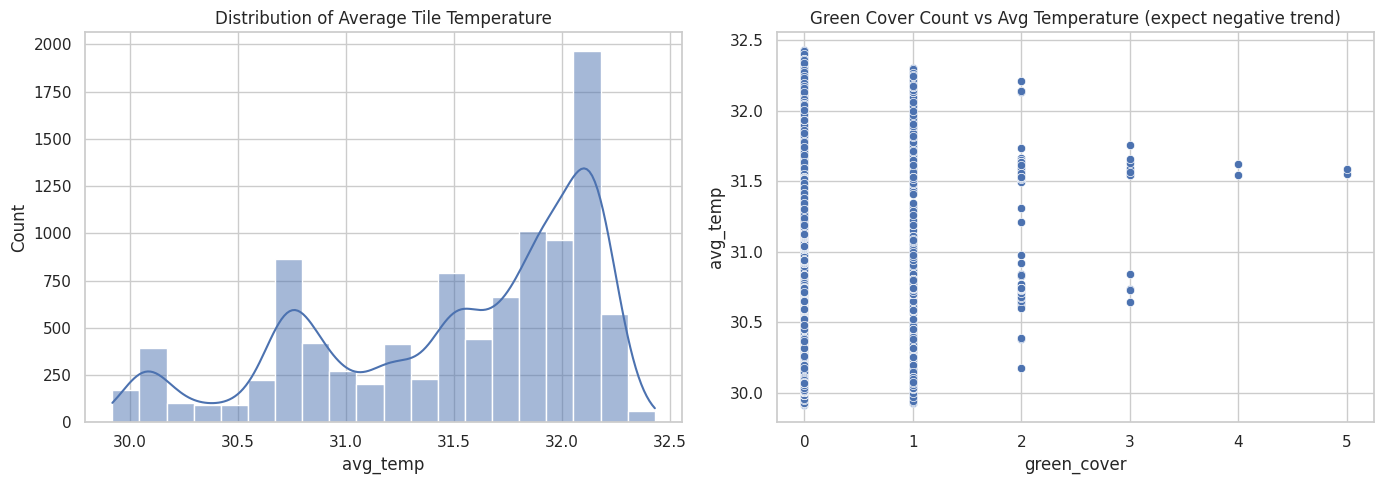

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(master_df["avg_temp"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Average Tile Temperature")

sns.scatterplot(data=master_df, x="green_cover", y="avg_temp", ax=axes[1])
axes[1].set_title("Green Cover Count vs Avg Temperature (expect negative trend)")

plt.tight_layout()
plt.show()

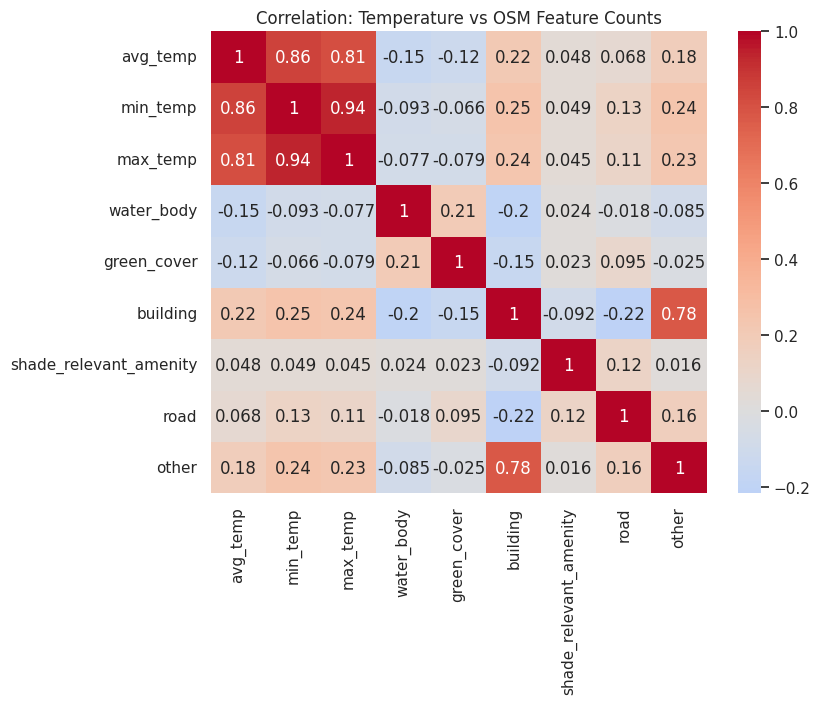

In [18]:
corr_cols = ["avg_temp", "min_temp", "max_temp"] + osm_cols
corr = master_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Temperature vs OSM Feature Counts")
plt.show()

In [19]:
corr_check = master_df[["avg_temp","green_cover","water_body"]].corr()["avg_temp"]
print(corr_check)
assert corr_check["green_cover"] < 0, "green_cover correlation not negative — reconsider using it"

avg_temp       1.000000
green_cover   -0.121315
water_body    -0.151071
Name: avg_temp, dtype: float64


**What to look for here:**

- <font size=5 color='darkkhaki'>Does green_cover negatively correlate with avg_temp?

 Yes, the correlation between avg_temp and green_cover is -0.12, indicating a slight negative correlation. This validates its use in the risk formula, as higher green cover is associated with lower average temperatures.

- <font size=5 color='darkkhaki'>Does water_body show a cooling effect?

Yes, the correlation between avg_temp and water_body is -0.15, suggesting a cooling effect as higher presence of water bodies correlates with lower average temperatures.

- <font size=5 color='darkkhaki'>Are building counts positively correlated with temperature?

 Yes, the correlation between avg_temp and building counts is 0.22, which is a positive correlation. This supports the urban heat island effect, where higher building density is associated with higher temperatures.

- <font size=5 color='darkkhaki'> Any tiles with extreme temps but no OSM data nearby — flag as a data gap, not necessarily true risk.

The notebook's data cleaning steps (specifically master_df[osm_cols].fillna(0)) converted any missing OSM data counts to 0, ensuring all tiles have a value (even if zero) for OSM features. Therefore, after processing, there are no explicit 'nulls' for OSM data to flag as data gaps in the final master_df. The analysis assumes that a count of 0 implies an absence of the feature rather than a data gap.

---
##<font size=5 color='salmon'> 9. Feature Engineering

Turn raw counts into normalized (0–1), comparable features.

**Reversal logic:** for temperature, *higher = worse*, so it stays as-is after
normalization. For green cover / water body / shade, *higher = better* (protective),
so we **reverse** them before combining into a risk score (so that in the final
formula, "higher normalized value" always means "higher risk contribution").

In [20]:
def min_max_normalize(series, cap_percentile=0.99):
    if series.max() == series.min():
        return pd.Series(0, index=series.index)
    upper = series.quantile(cap_percentile)
    capped = series.clip(upper=upper)
    if capped.max() == capped.min():
        return pd.Series(0, index=series.index)
    return (capped - capped.min()) / (capped.max() - capped.min())

feat_df = master_df.copy()

# --- Heat exposure (higher = worse, no reversal) ---
feat_df["norm_avg_temp"] = min_max_normalize(feat_df["avg_temp"])
feat_df["temp_range"] = feat_df["max_temp"] - feat_df["min_temp"]  # persistence/volatility proxy
feat_df["norm_temp_range"] = min_max_normalize(feat_df["temp_range"])

# --- Protective factors (higher = better -> REVERSE so higher = more risk) ---

feat_df["norm_green_cover"] = np.log1p(feat_df["green_cover"]) / np.log1p(feat_df["green_cover"].quantile(0.99))
feat_df["norm_green_cover"] = feat_df["norm_green_cover"].clip(0, 1)
feat_df["risk_green_cover"] = 1 - feat_df["norm_green_cover"]

feat_df["norm_water_body"] = np.log1p(feat_df["water_body"]) / np.log1p(feat_df["water_body"].quantile(0.99))
feat_df["norm_water_body"] = feat_df["norm_water_body"].clip(0, 1)
feat_df["risk_water_body"] = 1 - feat_df["norm_water_body"]

feat_df["norm_shade_amenity"] = np.log1p(feat_df["shade_relevant_amenity"]) / np.log1p(feat_df["shade_relevant_amenity"].quantile(0.99))
feat_df["norm_shade_amenity"] = feat_df["norm_shade_amenity"].clip(0, 1)
feat_df["risk_shade"] = 1 - feat_df["norm_shade_amenity"]

# --- Density factor (higher building count = worse, no reversal) ---
feat_df["norm_building_density"] = min_max_normalize(feat_df["building"])

feature_cols = [
    "norm_avg_temp", "norm_temp_range",
    "risk_green_cover", "risk_water_body", "risk_shade",
    "norm_building_density",
]

feat_df[["tile_id"] + feature_cols].head()

,tile_id,norm_avg_temp,norm_temp_range,risk_green_cover,risk_water_body,risk_shade,norm_building_density
0,0,0.953709,0.751315,1.0,1.0,1.0,0.103448
1,1,0.955610,0.760945,1.0,1.0,1.0,0.103448
2,2,0.957385,0.770371,1.0,1.0,1.0,0.068966
3,3,0.958990,0.779182,1.0,1.0,1.0,0.551724
4,4,0.960427,0.787173,1.0,1.0,1.0,0.517241


---
## <font size=5 color='salmon'>10. Risk Engine

Output: `risk_score` (0–100) + `risk_category` (Low / Normal / High / Critical).

In [21]:
# Placeholder weights
WEIGHTS = {
    "norm_avg_temp": 0.50,
    "norm_temp_range": 0.10,
    "risk_green_cover": 0.07,
    "risk_water_body": 0.05,
    "risk_shade": 0.08,
    "norm_building_density": 0.20,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1.0"

def compute_risk_score(row, weights=WEIGHTS):
    score = sum(row[feat] * w for feat, w in weights.items())
    return round(score * 100, 2)  # scale to 0-100

feat_df["risk_score"] = feat_df.apply(compute_risk_score, axis=1)

def categorize_risk(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Normal"
    elif score < 75:
        return "High"
    else:
        return "Critical"

feat_df["risk_category"] = feat_df["risk_score"].apply(categorize_risk)

feat_df[["tile_id", "avg_temp", "risk_score", "risk_category"]].sort_values("risk_score", ascending=False).head(10)

,tile_id,avg_temp,risk_score,risk_category
1908,1908,32.2974,94.66,Critical
2223,2223,32.2810,94.59,Critical
1904,1904,32.2358,94.40,Critical
1906,1906,32.2689,94.37,Critical
3063,3063,32.2309,94.25,Critical
2958,2958,32.2130,93.86,Critical
2748,2748,32.1954,93.49,Critical
2221,2221,32.2536,93.37,Critical
3275,3275,32.3102,93.35,Critical
3142,3142,32.1409,93.19,Critical


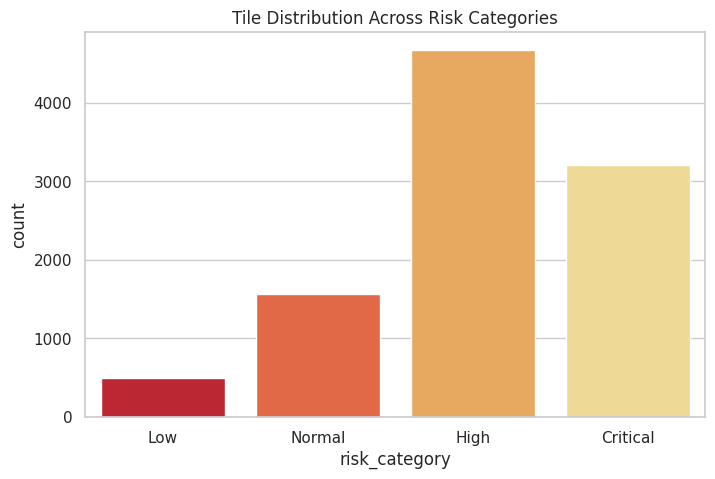

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=feat_df, x="risk_category", hue="risk_category", legend=False,
              order=["Low", "Normal", "High", "Critical"], palette="YlOrRd")
plt.title("Tile Distribution Across Risk Categories")
plt.show()

---
##<font size=5 color='salmon'> 11. Recommendation Engine

For each tile, identify which feature(s) contribute the **most** to its risk score,
and translate that into a plain-language cause + recommendation.

In [23]:
RECOMMENDATION_TEXT = {
    "norm_avg_temp": "High ambient heat exposure — prioritize cooling infrastructure (shaded shelters, misting points).",
    "norm_temp_range": "High temperature volatility — conditions swing rapidly; recommend real-time monitoring/alerts for this zone.",
    "risk_green_cover": "Low tree/green cover — recommend tree planting or green corridor initiatives.",
    "risk_water_body": "No nearby water body — recommend hydration points or misting stations.",
    "risk_shade": "Few shade-providing amenities nearby — recommend shaded rest shelters.",
    "norm_building_density": "High building density (urban heat island effect) — recommend reflective/cool roofing initiatives.",
}

# Precompute mean/std for each feature ONCE, before the recommendation loop
FEATURE_STATS = {
    feat: (feat_df[feat].mean(), feat_df[feat].std())
    for feat in WEIGHTS
}

def get_recommendation(row, weights=WEIGHTS, stats=FEATURE_STATS):
    contributions = {}
    for feat, w in weights.items():
        mean, std = stats[feat]
        z = (row[feat] - mean) / std if std > 0 else 0
        contributions[feat] = z * w
    top_feature = max(contributions, key=contributions.get)
    return top_feature, RECOMMENDATION_TEXT[top_feature]

feat_df[["top_risk_driver", "recommendation"]] = feat_df.apply(
    lambda row: pd.Series(get_recommendation(row)), axis=1
)

feat_df[["tile_id", "risk_score", "risk_category", "top_risk_driver", "recommendation"]].sort_values(
    "risk_score", ascending=False
).head(10)

,tile_id,risk_score,risk_category,top_risk_driver,recommendation
1908,1908,94.66,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
2223,2223,94.59,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
1904,1904,94.40,Critical,norm_building_density,High building density (urban heat island effec...
1906,1906,94.37,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
3063,3063,94.25,Critical,norm_building_density,High building density (urban heat island effec...
2958,2958,93.86,Critical,norm_building_density,High building density (urban heat island effec...
2748,2748,93.49,Critical,norm_building_density,High building density (urban heat island effec...
2221,2221,93.37,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
3275,3275,93.35,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
3142,3142,93.19,Critical,norm_building_density,High building density (urban heat island effec...


In [26]:
print(feat_df["top_risk_driver"].value_counts())

top_risk_driver
norm_avg_temp            5027
risk_shade               2064
norm_building_density    1869
norm_temp_range           882
risk_green_cover           91
risk_water_body             8
Name: count, dtype: int64


---
## <font size=5 color='salmon'>12. Projected Risk Score ("What-If" Simulator)

This section allows a user to see the projected risk score **if** a recommendation were implemented (e.g., 'what if green cover improved by 30%?').

This re-runs the risk formula with one feature's *risk contribution* reduced, holding everything else constant — a simple, explainable simulation (no retraining needed).

In [24]:
def simulate_improvement(row, feature_to_improve, improvement_pct, weights=WEIGHTS):
    """
    feature_to_improve: one of the risk_* / norm_* feature columns
    improvement_pct: 0-100, how much to reduce that feature's RISK contribution
    Returns: (original_score, projected_score, score_delta)
    """
    simulated_row = row.copy()
    reduction_factor = 1 - (improvement_pct / 100)
    simulated_row[feature_to_improve] = simulated_row[feature_to_improve] * reduction_factor

    original_score = row["risk_score"]
    projected_score = compute_risk_score(simulated_row, weights)
    return original_score, projected_score, round(original_score - projected_score, 2)

# Example: tile with the highest risk score — simulate improving green cover by 40%
example_tile = feat_df.sort_values("risk_score", ascending=False).iloc[0]
orig, projected, delta = simulate_improvement(example_tile, "risk_green_cover", improvement_pct=40)

print(f"Tile {int(example_tile['tile_id'])}")
print(f"Original risk score:  {orig}")
print(f"Projected risk score: {projected}  (if green cover risk improved by 40%)")
print(f"Improvement:          -{delta} points")

Tile 1908
Original risk score:  94.66
Projected risk score: 91.86  (if green cover risk improved by 40%)
Improvement:          -2.8 points


---
## <font size=5 color='salmon'> 13. Handoff : Export for Website Integration

Export the final table as JSON (one object per tile) in a clean, ready-to-consume format for the frontend/API layer.

In [25]:
output_cols = [
    "tile_id", "centroid_lat", "centroid_lon",
    "avg_temp", "min_temp", "max_temp",
    "risk_score", "risk_category",
    "top_risk_driver", "recommendation",
]

export_df = feat_df[output_cols].copy()

export_records = export_df.to_dict(orient="records")

with open("/content/tile_risk_scores.json", "w") as f:
    json.dump(export_records, f, indent=2)

print(f"Exported {len(export_records)} tiles to /content/tile_risk_scores.json")
export_df.head()

Exported 9941 tiles to /content/tile_risk_scores.json


,tile_id,centroid_lat,centroid_lon,avg_temp,min_temp,max_temp,risk_score,risk_category,top_risk_driver,recommendation
0,0,29.694510,-95.394746,32.1751,25.6710,38.1996,77.27,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
1,1,29.694529,-95.393713,32.1796,25.6781,38.2208,77.46,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
2,2,29.694547,-95.392679,32.1838,25.6849,38.2414,76.95,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
3,3,29.694566,-95.391645,32.1876,25.6912,38.2606,86.78,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...
4,4,29.694585,-95.390612,32.1910,25.6969,38.2780,86.24,Critical,norm_avg_temp,High ambient heat exposure — prioritize coolin...


---

## <font size=5 color='salmon'>Executive Summary: Heat Vulnerability & Outdoor Worker Safety Mapper</font>

<p style='color:#3366ff; font-size:16px;'>This notebook outlines the development of 'Chhaya,' a comprehensive system designed to map heat vulnerability and enhance outdoor worker safety. Leveraging a robust data pipeline, Chhaya integrates heat data from FortyGuard with rich contextual information from OpenStreetMap to identify high-risk areas and propose actionable recommendations.</p>

### <font size=4 color='darkcyan'>Key Stages & Innovations:</font>

1.  **Data Acquisition & Validation:**
    *   Successfully loaded raw heat data (FortyGuard) and geospatial context (OpenStreetMap) from an SQLite database.
    *   Performed thorough data quality checks, ensuring data integrity for subsequent analyses.

2.  **Data Transformation & Integration:**
    *   **FortyGuard Data Flattening:** Converted GeoJSON heat tile data into a structured DataFrame, computing centroids for each tile.
    *   **OpenStreetMap Data Flattening:** Processed complex OSM `nodes` and `ways` data, resolving geometries and unifying them into a point-level dataset.
    *   **Feature Categorization:** Systematically categorized OSM features (e.g., green cover, water bodies, buildings, amenities) into vulnerability-relevant groups.
    *   **Spatial Join:** Efficiently assigned OSM points to corresponding FortyGuard heat tiles using optimized point-in-polygon tests, creating a master tile-level table.

3.  **Exploratory Data Analysis (EDA):**
    *   Analyzed temperature distributions and feature counts.
    *   **Confirmed expected correlations:** Identified a negative correlation between `avg_temp` and `green_cover` (-0.12) and `water_body` (-0.15), validating their cooling effects. A positive correlation with `building` counts (0.22) supported the urban heat island effect.

4.  **Feature Engineering:**
    *   Developed a min-max normalization strategy, including percentile capping to handle outliers.
    *   Implemented a crucial **reversal logic** for protective features (green cover, water bodies, shade) to align their contributions with risk (higher value = higher risk contribution).

5.  **Risk Engine:**
    *   Computed a quantitative `risk_score` (0-100) for each tile based on weighted normalized features.
    *   Categorized tiles into `risk_category` (Low, Normal, High, Critical) for intuitive interpretation.

6.  **Recommendation Engine:**
    *   Identified the **top contributing feature** to each tile's risk score by analyzing feature contributions based on z-scores and weights.
    *   Generated specific, plain-language `recommendations` linked to the top risk driver, enabling targeted interventions (e.g., "Low tree/green cover — recommend tree planting").

7.  **Projected Risk Score ("What-If" Simulator):**
    *   Implemented a simulator to demonstrate the potential reduction in `risk_score` if a specific recommendation (e.g., improving green cover) were implemented, providing tangible insights into intervention effectiveness.

### <font size=4 color='darkcyan'>Conclusion & Handoff:</font>

The project successfully delivers a robust, interpretable, and actionable heat vulnerability mapping tool. The final dataset, enriched with risk scores, categories, and targeted recommendations, has been exported as a clean JSON file (`tile_risk_scores.json`), ready for seamless integration with frontend applications or API layers. This comprehensive output empowers stakeholders to make informed decisions for mitigating heat risks and enhancing outdoor worker safety.